# Assignment 2 — BST vs Red-Black Tree Benchmark Analysis
Run all cells in order after placing `benchmark_results.csv` and `mergesort_results.csv` in the same folder as this notebook.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

COLORS = {'BST': '#4C72B0', 'RBT': '#DD8452', 'MergeSort': '#55A868'}
DIST_ORDER = ['Fully Random', 'Nearly Sorted 1%', 'Nearly Sorted 5%', 'Nearly Sorted 10%']
OP_ORDER   = ['INSERT', 'CONTAINS', 'DELETE', 'SORT']
print('Libraries loaded.')

Libraries loaded.


In [22]:
# ── Load data ──────────────────────────────────────────────────
df_trees  = pd.read_csv('benchmark_results.csv')
df_merge  = pd.read_csv('mergesort_results.csv')

# Convert ns → ms for readability
for df in [df_trees, df_merge]:
    df['median_ms'] = df['median_ns'] / 1e6
    df['mean_ms']   = df['mean_ns']   / 1e6
    df['std_ms']    = df['std_ns']    / 1e6

# Enforce category order
df_trees['distribution'] = pd.Categorical(df_trees['distribution'], categories=DIST_ORDER, ordered=True)
df_trees['operation']    = pd.Categorical(df_trees['operation'],    categories=OP_ORDER,   ordered=True)

bst = df_trees[df_trees['tree'] == 'BST'].sort_values(['distribution','operation'])
rbt = df_trees[df_trees['tree'] == 'RBT'].sort_values(['distribution','operation'])

print('Shape (trees):', df_trees.shape)
print('Shape (merge):', df_merge.shape)
df_trees.head(8)

Shape (trees): (32, 10)
Shape (merge): (4, 9)


,tree,distribution,operation,median_ns,mean_ns,std_ns,speedup,median_ms,mean_ms,std_ms
0,BST,Fully Random,INSERT,13235700,14540460.0,1967163.77,NaN,13.2357,14.54046,1.967164
1,RBT,Fully Random,INSERT,15714300,15473840.0,718967.09,0.842,15.7143,15.47384,0.718967
2,BST,Fully Random,CONTAINS,8920700,8861720.0,486497.25,NaN,8.9207,8.86172,0.486497
3,RBT,Fully Random,CONTAINS,7185700,7690400.0,933104.16,1.241,7.1857,7.69040,0.933104
4,BST,Fully Random,DELETE,3623000,3631680.0,164097.76,NaN,3.6230,3.63168,0.164098
5,RBT,Fully Random,DELETE,3400100,3387140.0,110925.50,1.066,3.4001,3.38714,0.110925
6,BST,Fully Random,SORT,14165800,14299380.0,570488.60,NaN,14.1658,14.29938,0.570489
7,RBT,Fully Random,SORT,14859700,15122400.0,561529.25,0.953,14.8597,15.12240,0.561529


## 1. All Operations — BST vs RBT per Distribution

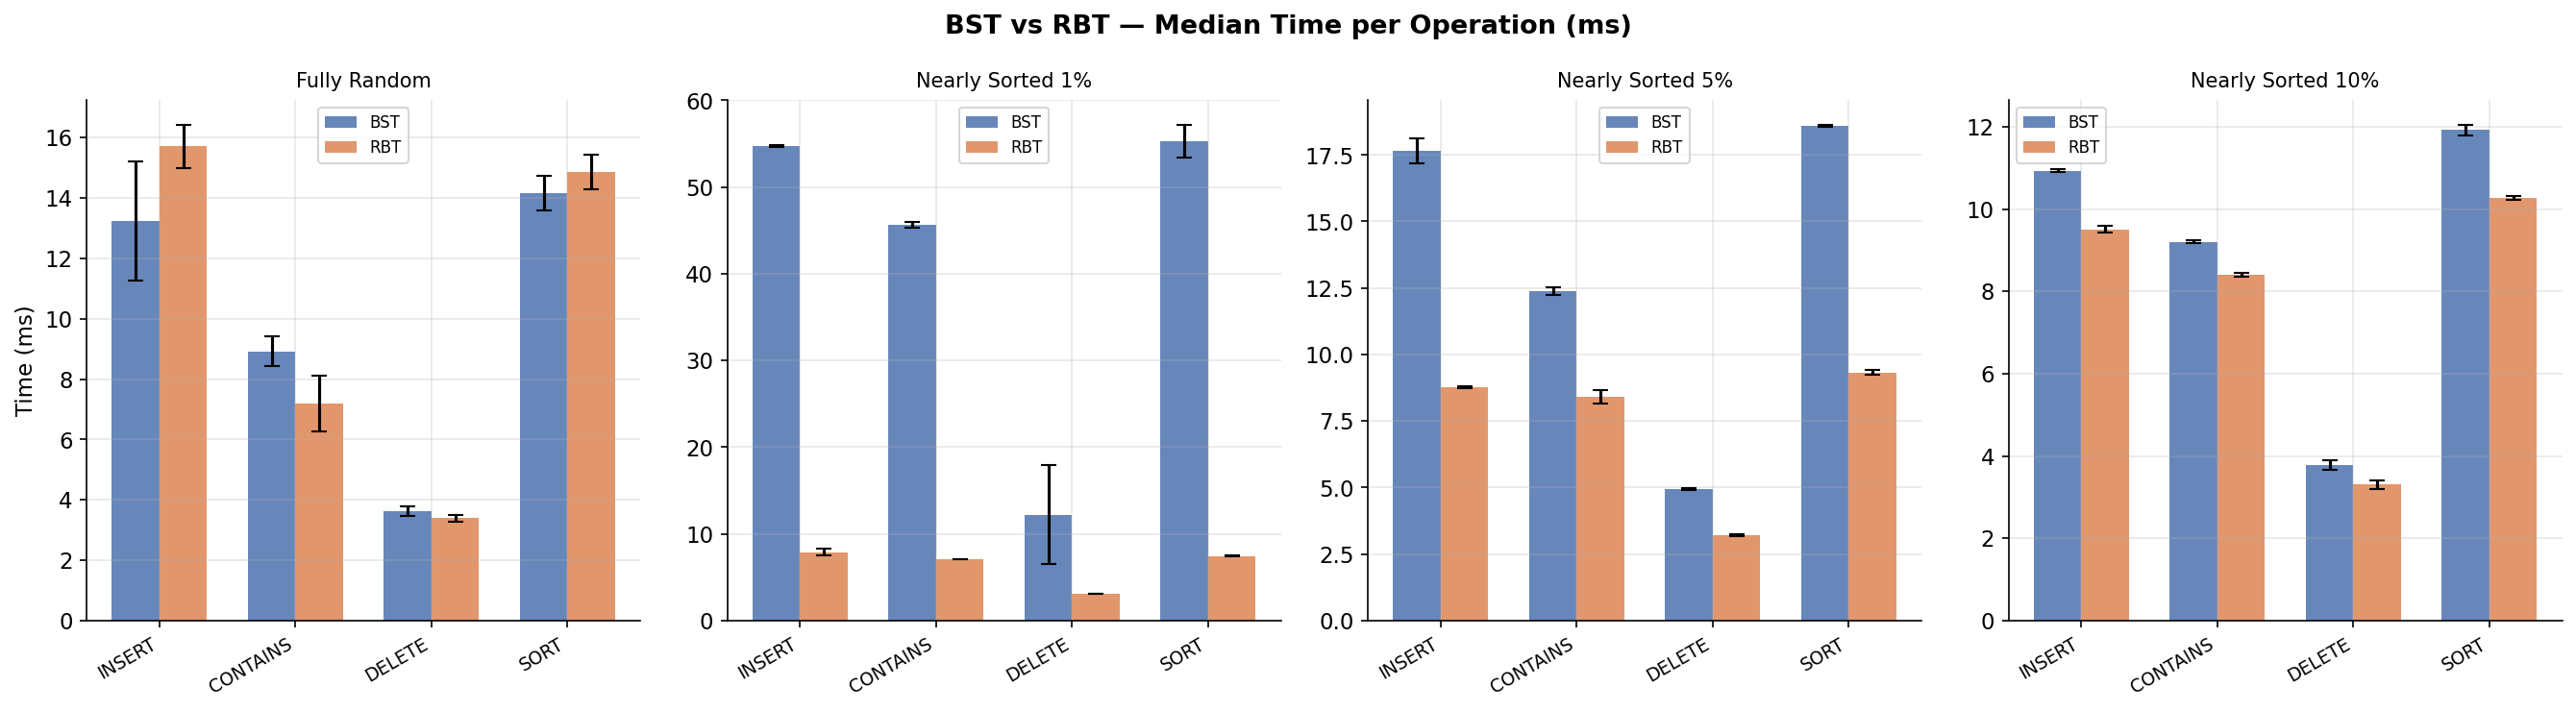

Saved: plot_all_ops.png


In [23]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)
fig.suptitle('BST vs RBT — Median Time per Operation (ms)', fontsize=13, fontweight='bold')

for ax, dist in zip(axes, DIST_ORDER):
    bst_d = bst[bst['distribution'] == dist].sort_values('operation')
    rbt_d = rbt[rbt['distribution'] == dist].sort_values('operation')

    x    = np.arange(len(OP_ORDER))
    w    = 0.35

    bars_bst = ax.bar(x - w/2, bst_d['median_ms'], w,
                      label='BST', color=COLORS['BST'],
                      yerr=bst_d['std_ms'], capsize=4, alpha=0.85)
    bars_rbt = ax.bar(x + w/2, rbt_d['median_ms'], w,
                      label='RBT', color=COLORS['RBT'],
                      yerr=rbt_d['std_ms'], capsize=4, alpha=0.85)

    ax.set_title(dist, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(OP_ORDER, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Time (ms)' if ax == axes[0] else '')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('plot_all_ops.png', bbox_inches='tight')
plt.show()
print('Saved: plot_all_ops.png')

## 2. INSERT — Height After Insertion
> Paste your height output from the console here — replace the values in `heights`.

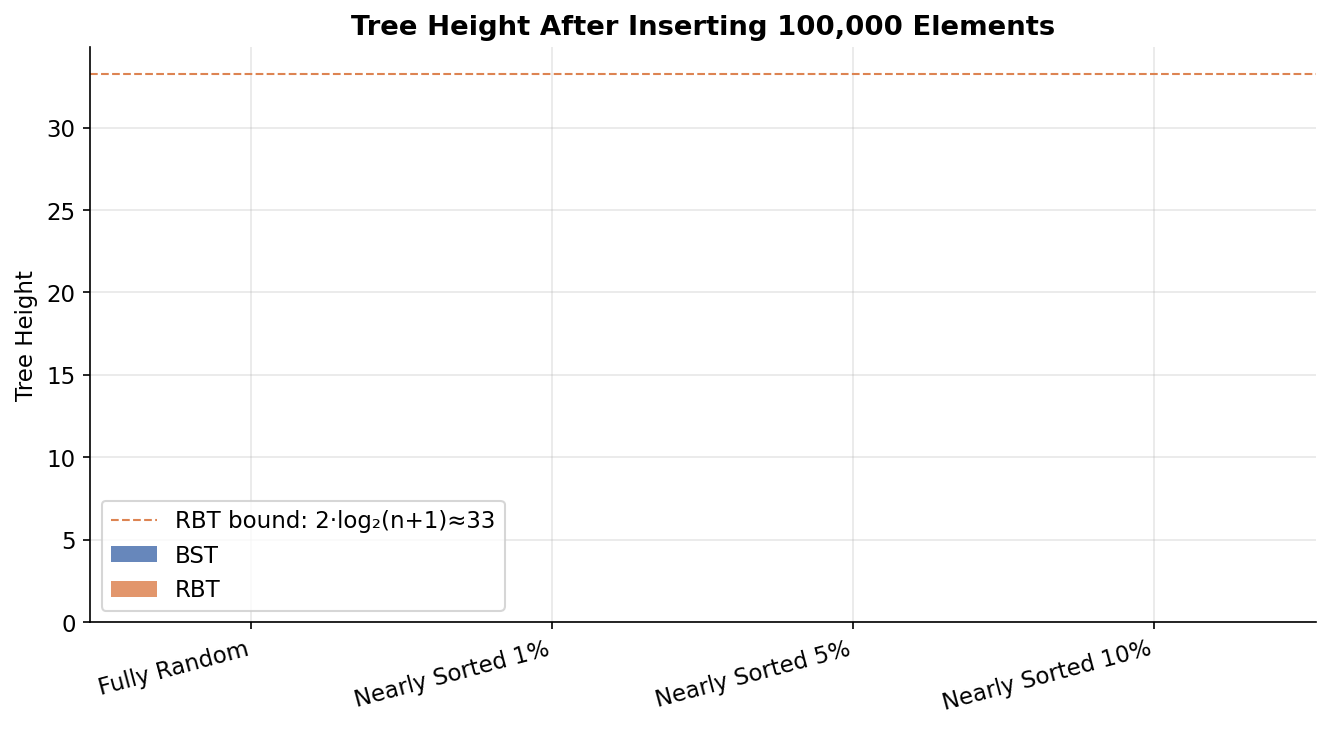

Saved: plot_heights.png


In [24]:
# ── EDIT THESE VALUES — copy from console HEIGHT output ────────
heights = {
    'Fully Random':       {'BST': 0,  'RBT': 0},   # replace 0s
    'Nearly Sorted 1%':   {'BST': 0,  'RBT': 0},
    'Nearly Sorted 5%':   {'BST': 0,  'RBT': 0},
    'Nearly Sorted 10%':  {'BST': 0,  'RBT': 0},
}

df_h = pd.DataFrame(heights).T.reset_index()
df_h.columns = ['distribution', 'BST', 'RBT']

x = np.arange(len(DIST_ORDER))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, df_h['BST'], w, label='BST', color=COLORS['BST'], alpha=0.85)
ax.bar(x + w/2, df_h['RBT'], w, label='RBT', color=COLORS['RBT'], alpha=0.85)

# theoretical bounds
n = 100_000
ax.axhline(2 * np.log2(n + 1), color=COLORS['RBT'], linestyle='--',
           linewidth=1, label=f'RBT bound: 2·log₂(n+1)≈{2*np.log2(n+1):.0f}')

ax.set_xticks(x)
ax.set_xticklabels(DIST_ORDER, rotation=15, ha='right')
ax.set_ylabel('Tree Height')
ax.set_title('Tree Height After Inserting 100,000 Elements', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('plot_heights.png', bbox_inches='tight')
plt.show()
print('Saved: plot_heights.png')

## 3. INSERT Time — Effect of Distribution on Each Tree

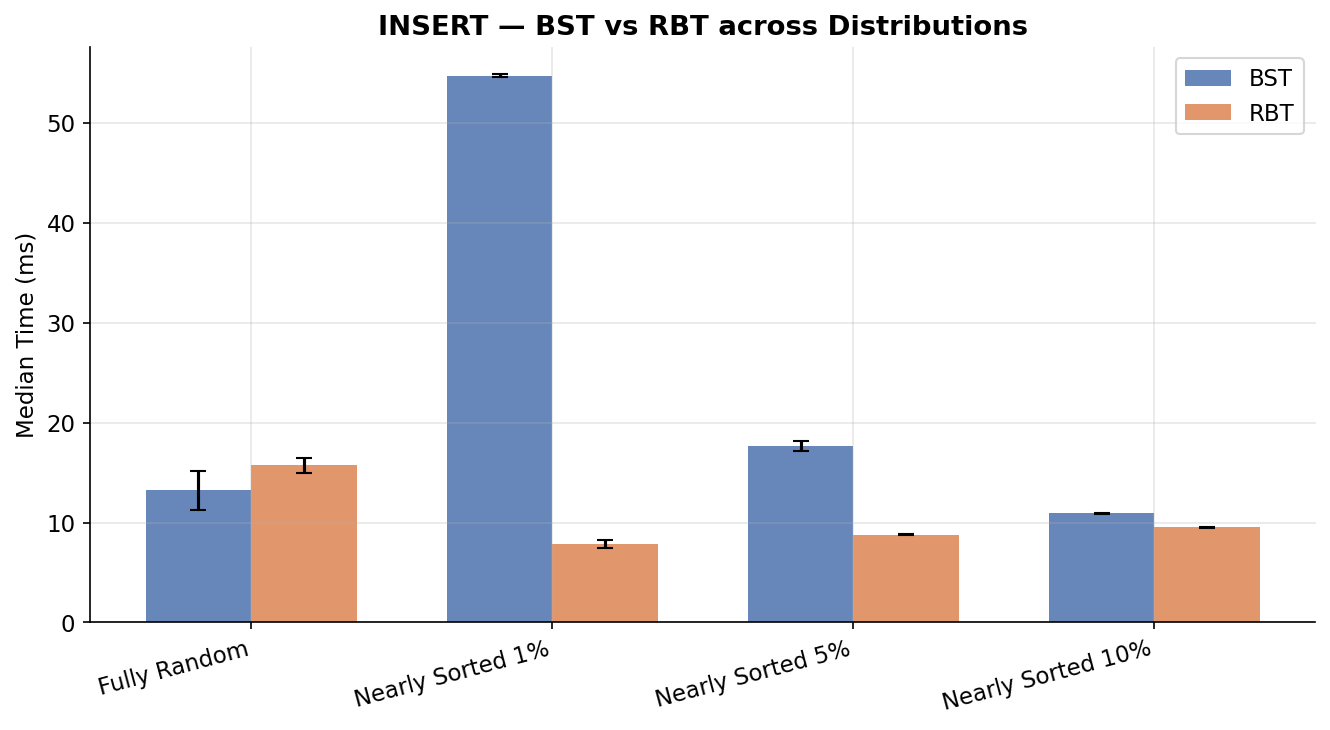

In [25]:
insert_bst = bst[bst['operation'] == 'INSERT'].sort_values('distribution')
insert_rbt = rbt[rbt['operation'] == 'INSERT'].sort_values('distribution')

x = np.arange(len(DIST_ORDER))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, insert_bst['median_ms'], w, label='BST',
       yerr=insert_bst['std_ms'], capsize=4,
       color=COLORS['BST'], alpha=0.85)
ax.bar(x + w/2, insert_rbt['median_ms'], w, label='RBT',
       yerr=insert_rbt['std_ms'], capsize=4,
       color=COLORS['RBT'], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(DIST_ORDER, rotation=15, ha='right')
ax.set_ylabel('Median Time (ms)')
ax.set_title('INSERT — BST vs RBT across Distributions', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('plot_insert.png', bbox_inches='tight')
plt.show()

## 4. Speed-up: How Many Times Faster is RBT than BST?

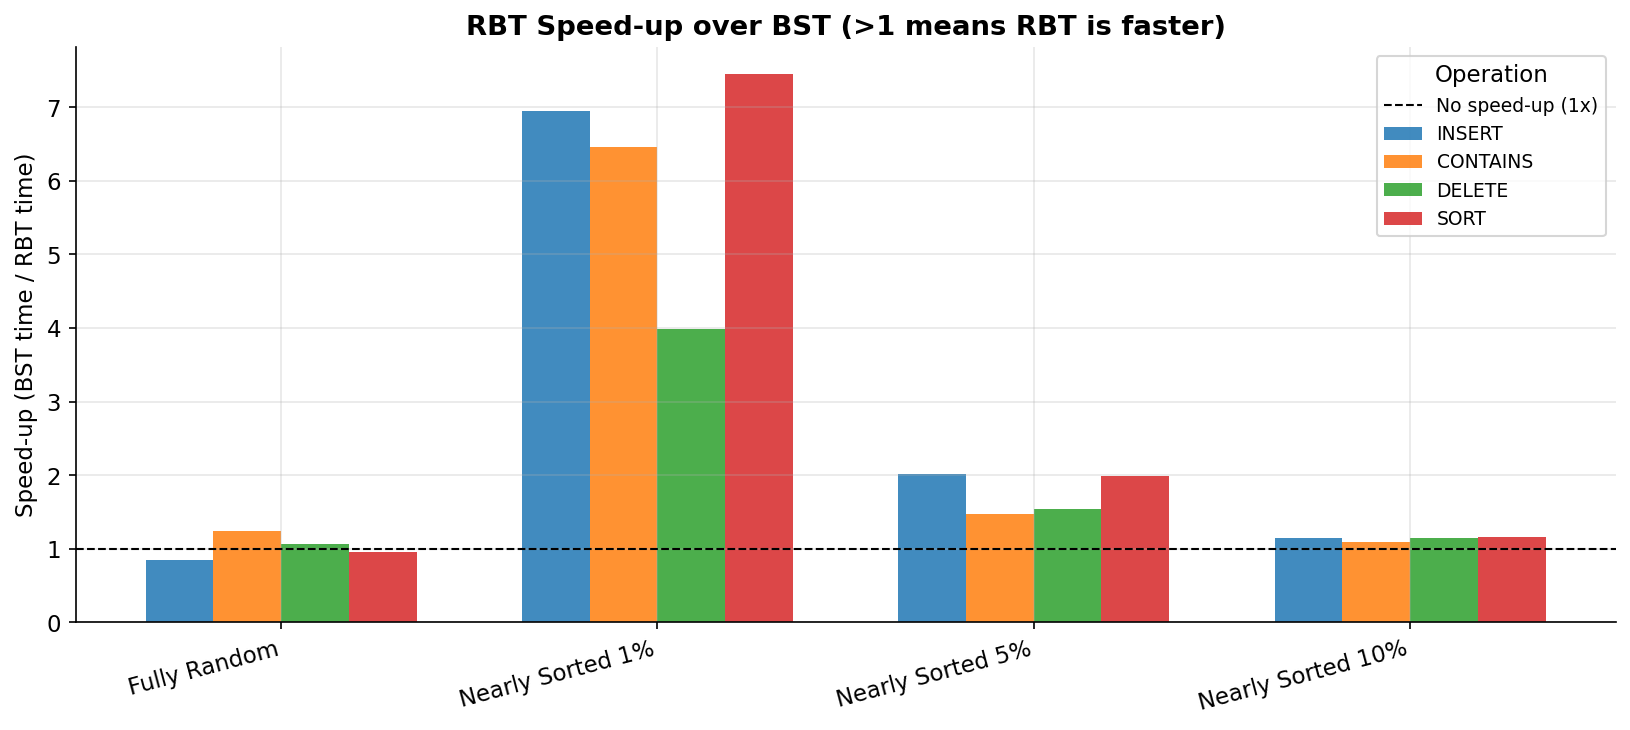

In [26]:
# compute speed-up per (distribution, operation)
merged = pd.merge(
    bst[['distribution','operation','median_ms']].rename(columns={'median_ms':'bst_ms'}),
    rbt[['distribution','operation','median_ms']].rename(columns={'median_ms':'rbt_ms'}),
    on=['distribution','operation']
)
merged['speedup'] = merged['bst_ms'] / merged['rbt_ms']

fig, ax = plt.subplots(figsize=(11, 5))

x     = np.arange(len(DIST_ORDER))
w     = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]

for i, op in enumerate(OP_ORDER):
    op_data = merged[merged['operation'] == op].sort_values('distribution')
    ax.bar(x + offsets[i] * w, op_data['speedup'], w, label=op, alpha=0.85)

ax.axhline(1.0, color='black', linestyle='--', linewidth=1, label='No speed-up (1x)')
ax.set_xticks(x)
ax.set_xticklabels(DIST_ORDER, rotation=15, ha='right')
ax.set_ylabel('Speed-up (BST time / RBT time)')
ax.set_title('RBT Speed-up over BST (>1 means RBT is faster)', fontweight='bold')
ax.legend(title='Operation', fontsize=9)

plt.tight_layout()
plt.savefig('plot_speedup.png', bbox_inches='tight')
plt.show()

## 5. Sort Comparison — Tree Sort vs MergeSort

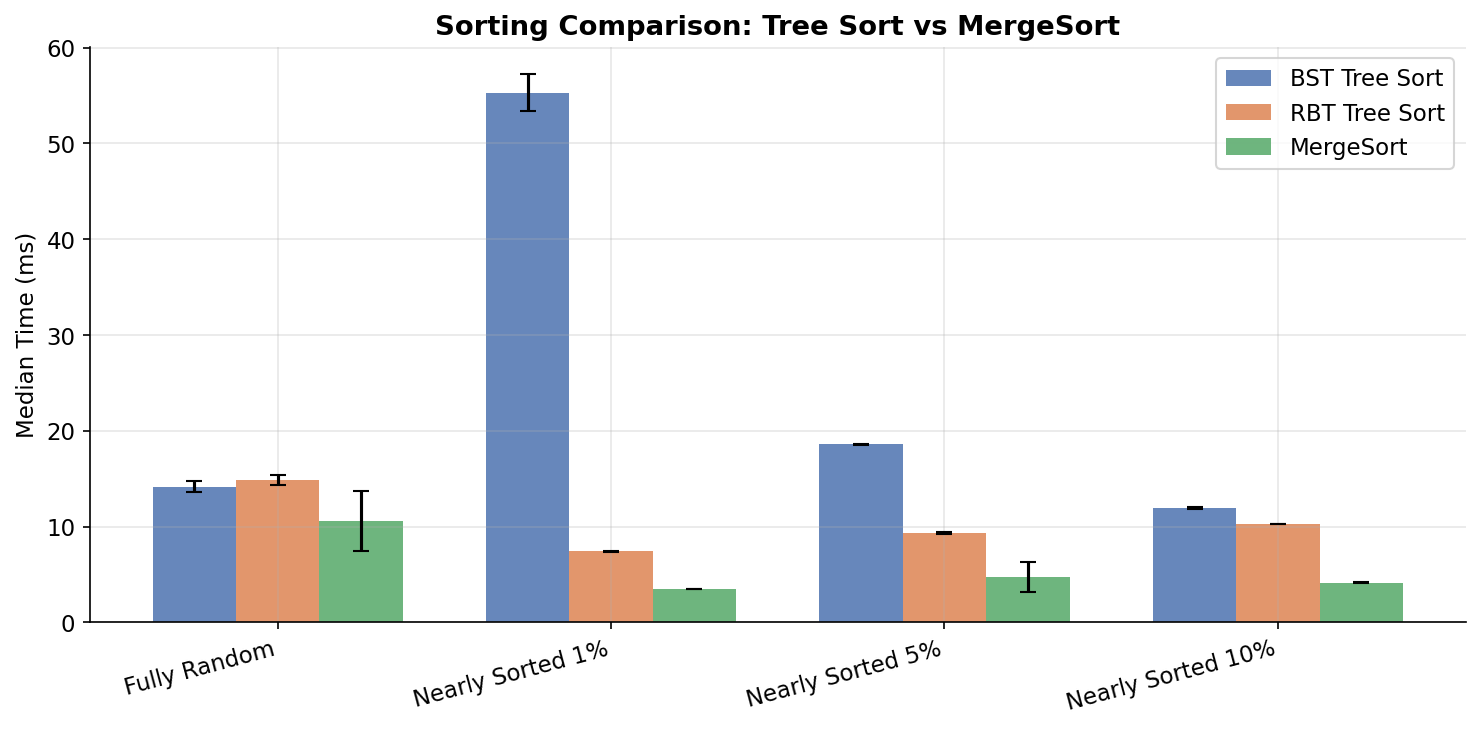

In [27]:
sort_bst   = bst[bst['operation'] == 'SORT'].sort_values('distribution')
sort_rbt   = rbt[rbt['operation'] == 'SORT'].sort_values('distribution')
sort_merge = df_merge.sort_values('distribution')

x = np.arange(len(DIST_ORDER))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w,   sort_bst['median_ms'],   w, label='BST Tree Sort',
       yerr=sort_bst['std_ms'],   capsize=4, color=COLORS['BST'],       alpha=0.85)
ax.bar(x,       sort_rbt['median_ms'],   w, label='RBT Tree Sort',
       yerr=sort_rbt['std_ms'],   capsize=4, color=COLORS['RBT'],       alpha=0.85)
ax.bar(x + w,   sort_merge['median_ms'], w, label='MergeSort',
       yerr=sort_merge['std_ms'], capsize=4, color=COLORS['MergeSort'], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(DIST_ORDER, rotation=15, ha='right')
ax.set_ylabel('Median Time (ms)')
ax.set_title('Sorting Comparison: Tree Sort vs MergeSort', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('plot_sort_comparison.png', bbox_inches='tight')
plt.show()

## 6. Nearly Sorted Effect — BST Degradation

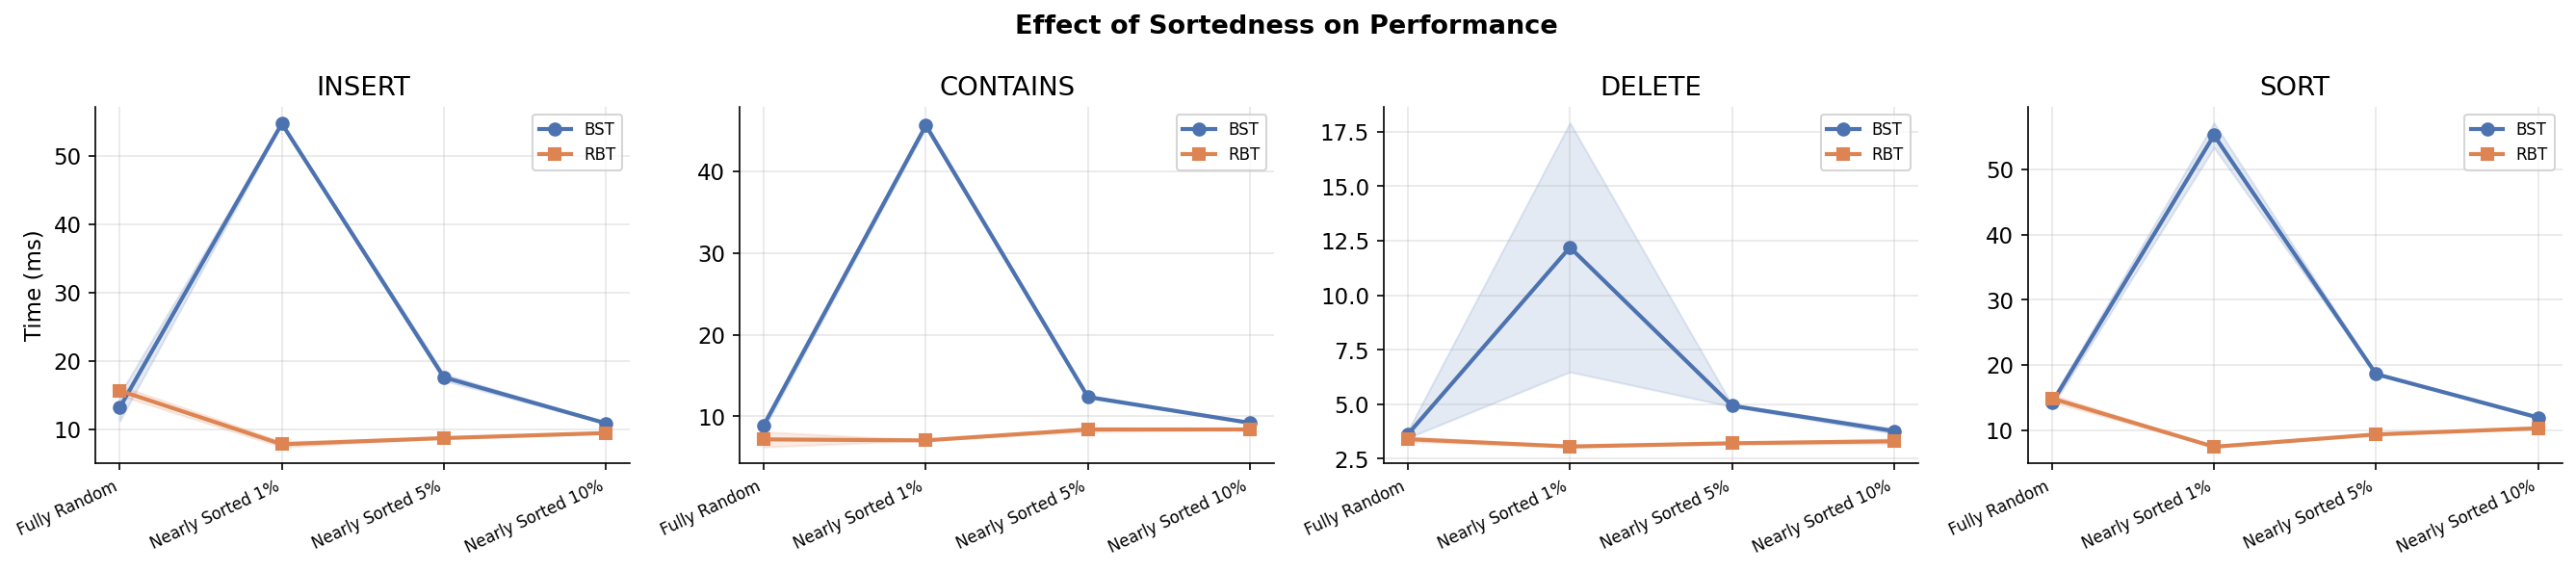

Saved: plot_degradation.png


In [28]:
# show how BST degrades as input becomes more sorted
# x-axis: disorder percentage, y-axis: time

disorder = [0, 1, 5, 10]   # 0 = fully random used as baseline label

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
fig.suptitle('Effect of Sortedness on Performance', fontsize=13, fontweight='bold')

for ax, op in zip(axes, OP_ORDER):
    bst_op = bst[bst['operation'] == op].sort_values('distribution')
    rbt_op = rbt[rbt['operation'] == op].sort_values('distribution')

    ax.plot(DIST_ORDER, bst_op['median_ms'],
            marker='o', color=COLORS['BST'], label='BST', linewidth=2)
    ax.fill_between(DIST_ORDER,
                    bst_op['median_ms'] - bst_op['std_ms'],
                    bst_op['median_ms'] + bst_op['std_ms'],
                    color=COLORS['BST'], alpha=0.15)

    ax.plot(DIST_ORDER, rbt_op['median_ms'],
            marker='s', color=COLORS['RBT'], label='RBT', linewidth=2)
    ax.fill_between(DIST_ORDER,
                    rbt_op['median_ms'] - rbt_op['std_ms'],
                    rbt_op['median_ms'] + rbt_op['std_ms'],
                    color=COLORS['RBT'], alpha=0.15)

    ax.set_title(op)
    ax.set_xticklabels(DIST_ORDER, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('Time (ms)' if ax == axes[0] else '')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('plot_degradation.png', bbox_inches='tight')
plt.show()
print('Saved: plot_degradation.png')

## 7. Summary Statistics Table

In [29]:
summary = merged.copy()
summary['bst_ms']  = summary['bst_ms'].map('{:,.2f}'.format)
summary['rbt_ms']  = summary['rbt_ms'].map('{:,.2f}'.format)
summary['speedup'] = summary['speedup'].map('{:.2f}x'.format)
summary.columns    = ['Distribution', 'Operation', 'BST (ms)', 'RBT (ms)', 'Speed-up']

display(summary.style
    .set_caption('BST vs RBT — All Operations (median time in ms)')
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-weight','bold'),('font-size','13px')]}])
)

,Distribution,Operation,BST (ms),RBT (ms),Speed-up
0,Fully Random,INSERT,13.24,15.71,0.84x
1,Fully Random,CONTAINS,8.92,7.19,1.24x
2,Fully Random,DELETE,3.62,3.40,1.07x
3,Fully Random,SORT,14.17,14.86,0.95x
4,Nearly Sorted 1%,INSERT,54.72,7.87,6.95x
5,Nearly Sorted 1%,CONTAINS,45.62,7.07,6.46x
6,Nearly Sorted 1%,DELETE,12.20,3.06,3.98x
7,Nearly Sorted 1%,SORT,55.30,7.43,7.44x
8,Nearly Sorted 5%,INSERT,17.65,8.77,2.01x
9,Nearly Sorted 5%,CONTAINS,12.38,8.40,1.47x


In [30]:
print('All plots saved:')
print('  plot_all_ops.png')
print('  plot_heights.png      ← fill in height values first')
print('  plot_insert.png')
print('  plot_speedup.png')
print('  plot_sort_comparison.png')
print('  plot_degradation.png')

All plots saved:
  plot_all_ops.png
  plot_heights.png      ← fill in height values first
  plot_insert.png
  plot_speedup.png
  plot_sort_comparison.png
  plot_degradation.png
